In [1]:
from __future__ import absolute_import,division,print_function

import tensorflow as tf
import numpy as np


In [2]:
# MNIST dataset parameters
num_classes = 10 # total classes (0-9 digits)
num_features = 784 # data features in our input (28*28 = 784)

# Training Parameter
learning_rate=0.001
training_steps=3000
batch_size = 256
display_step = 100

# Neural Network Parameters
n_hidden_1 = 128 # 1st layer number of neurons
n_hidden_2 = 256 # 2nd layer number of neurons

In [3]:
# Prepare MNIST data.

# download the dataset

from tensorflow.keras.datasets import mnist

(x_train,y_train), (x_test,y_test)=mnist.load_data()

# convert to float32
x_train,x_test=np.array(x_train,np.float32), np.array(x_test,np.float32)

# Flatten images to 1-D vector of 784 features (28* 28)
x_train,x_test = x_train.reshape([-1,num_features]),x_test.reshape([-1,num_features])

# Normalize image values from [0, 255] ---> [0, 1]
x_train,x_test = x_train/255.,x_test/255.

* repeat() makes the dataset available again and again.
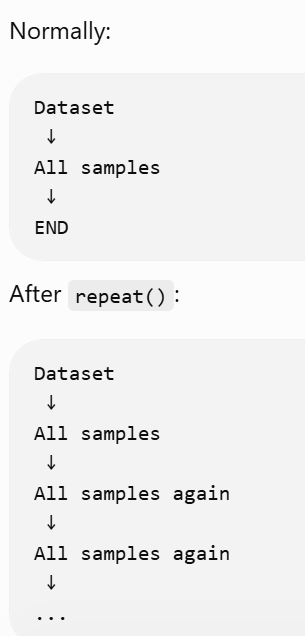

* This randomly changes the order of the training samples.
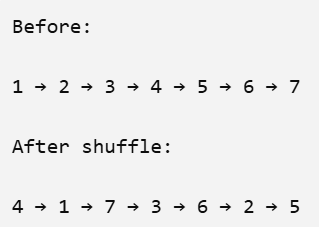

It means TensorFlow maintains a buffer containing up to 5,000 elements from which it randomly selects samples.

It does not mean "shuffle exactly 5000 times

- prefetch() allows TensorFlow to prepare the next batch while the model is processing the current batch.
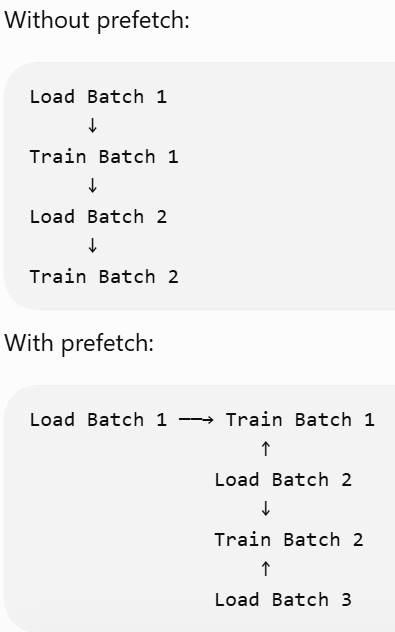

In [4]:
# Use tf.data API to shuffle and batch data
train_data = tf.data.Dataset.from_tensor_slices((x_train,y_train))#It pairs the corresponding x and y values.
train = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

* Initializer decides the initial values of weights and biases before training starts.
`The neural network cannot start learning with unknown weights, so an initializer gives the weights an initial value.`
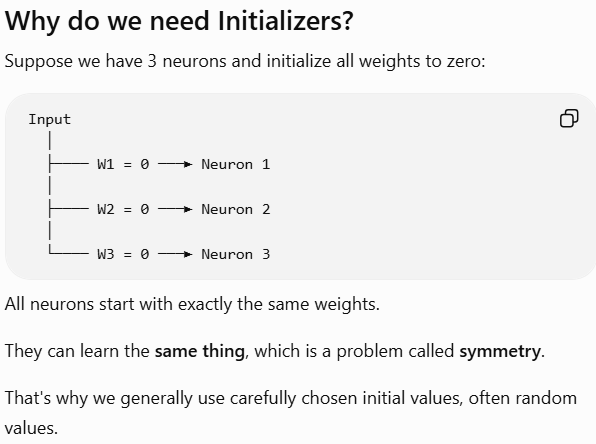

In [5]:
# store layers weights and biases
# A random number generator to intialize weights

random_normal = tf.initializers.RandomNormal()

weights = {
    "h1":tf.Variable(random_normal([num_features,n_hidden_1])),
    "h2":tf.Variable(random_normal([n_hidden_1,n_hidden_2])),
    "out":tf.Variable(random_normal([n_hidden_2,num_classes]))
}

biases = {
    "b1":tf.Variable(random_normal([n_hidden_1])),
    "b2":tf.Variable(random_normal([n_hidden_2])),
    "out":tf.Variable(random_normal([num_classes]))
}

In [6]:
print("W_1 Shape: ",weights['h1'].shape)
print("W_2 Shape: ",weights['h2'].shape)
print("W_out Shape: ",weights['out'].shape)

print("W_1 Shape: ",biases['b1'].shape)
print("W_2 Shape: ",biases['b2'].shape)
print("W_out Shape: ",biases['out'].shape)

W_1 Shape:  (784, 128)
W_2 Shape:  (128, 256)
W_out Shape:  (256, 10)
W_1 Shape:  (128,)
W_2 Shape:  (256,)
W_out Shape:  (10,)


In [7]:
# Create model

def neural_net(x):
  # Hidden fully connected layer with 128 neurons.
  layer_1 = tf.add(tf.matmul(x,weights['h1']),biases['b1']) # Z1
  # Apply sigmoid to layer_1 output for non-linearity
  layer_1 = tf.nn.sigmoid(layer_1) # A1

  # Hidden fully connected layer with 256 neurons.
  layer_2 = tf.add(tf.matmul(layer_1,weights['h2']),biases['b2']) # Z2

  # apply sigmoid to layer_2 output
  layer_2 = tf.nn.sigmoid(layer_2)

  # Output fully connected layer with a neuron for each class --> 10
  out_layer = tf.add(tf.matmul(layer_2,weights['out']),biases['out'])

  # Apply softmax to normalize the logits to a probablity distribution
  return tf.nn.softmax(out_layer)

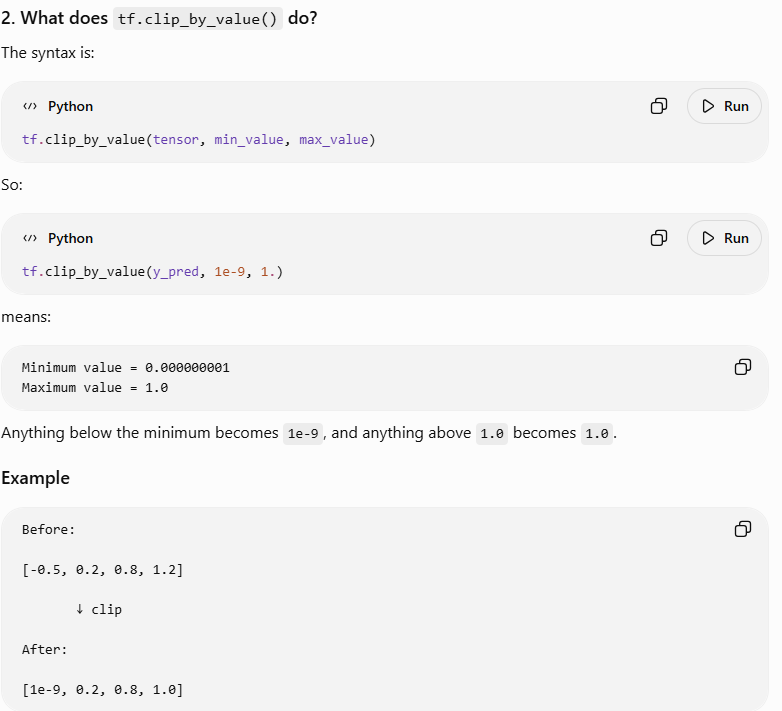


* Keep every value in y_pred between 1e-9 and 1.0.

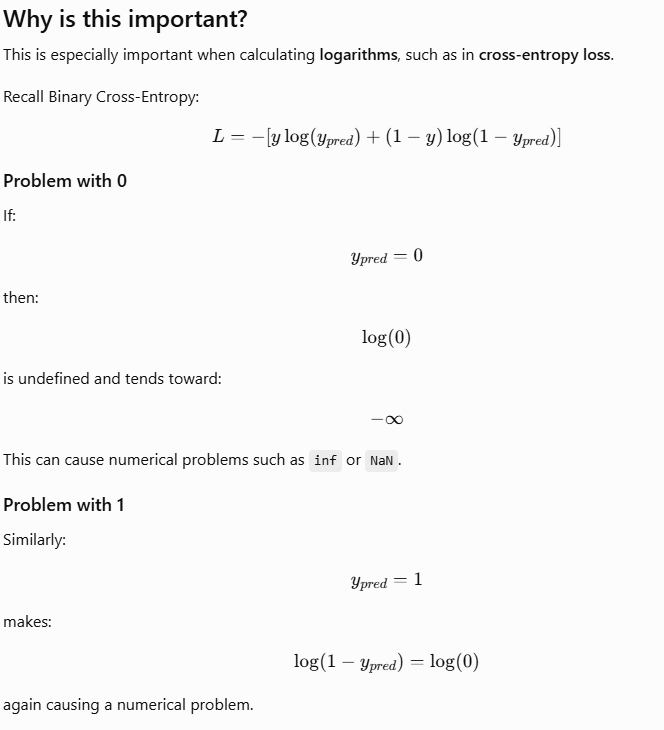

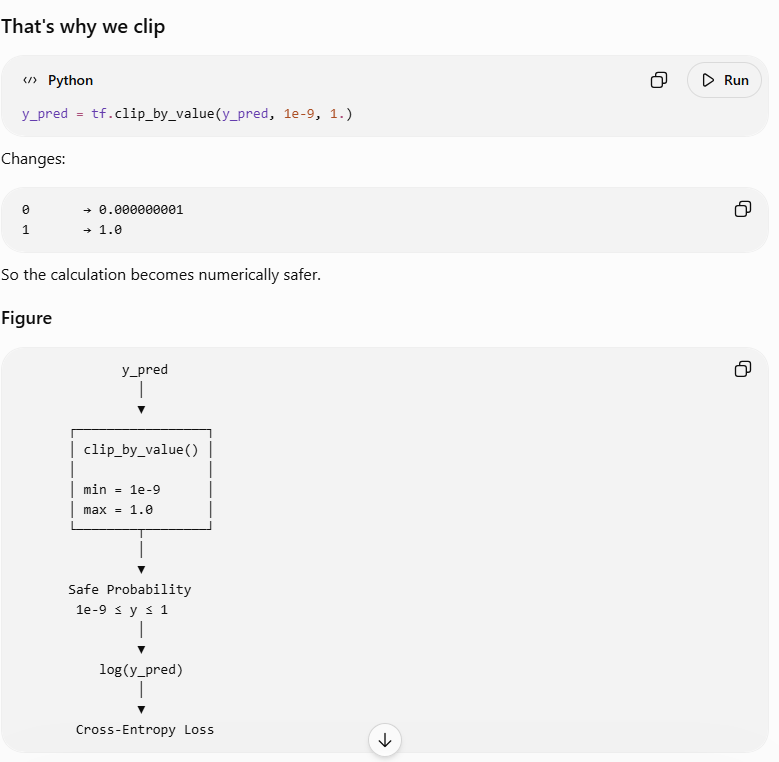

In [8]:
# Cross-Entropy loss function
def cross_entropy(y_pred,y_true):
  # Encode label to a one hot vector
  y_true = tf.one_hot(y_true,depth=num_classes)

  # Clip predictions values to avoid log(0) error.
  y_pred = tf.clip_by_value(y_pred,1e-9,1.)

  # cross-entropy loss
  return tf.reduce_mean(-tf.reduce_sum(y_true*tf.math.log(y_pred)))

# Accuracy metrics
def accuracy(y_pred,y_true):
  # Predicted class is the index of highest score in prediction vector( ie argmax)
  correct_prediction = tf.equal(tf.argmax(y_pred,1),tf.cast(y_true,tf.int64))
  return tf.reduce_mean(tf.cast(correct_prediction,tf.float32),axis=-1)

# Stochastic gradient descent optimizer
optimizer = tf.optimizers.SGD(learning_rate)

*What is GradientTape?

`tf.GradientTape() is a TensorFlow tool that records the mathematical operations during the forward pass and uses them to calculate gradients for backpropagation.`

- In simple words:

`GradientTape tells us how much each weight and bias contributed to the error (loss).`

In [9]:
# Optimizing process
def run_optimization(x,y):
  # Wrap computation inside a GradientTape for automatic differentiation
  with tf.GradientTape() as g:
    pred = neural_net(x)
    loss = cross_entropy(pred,y)

  # Variable to update ie trainable variables during back propagation
  trainable_variables = list(weights.values()) + list(biases.values())

  # compute gradients
  gradients = g.gradient(loss,trainable_variables)

  # Update W and b following gradients
  optimizer.apply_gradients(zip(gradients,trainable_variables))

In [10]:
for step,(batch_x,batch_y) in enumerate(train.take(training_steps),1):
  # Run the optmizatoin top update W and b values after each batch
  run_optimization(batch_x,batch_y)

  if step % display_step == 0:
    pred = neural_net(batch_x)
    loss = cross_entropy(pred,batch_y)
    acc = accuracy(pred,batch_y)
    print(f"step: {step}, loss: {loss}, accuracy: {acc}")

step: 100, loss: 558.06494140625, accuracy: 0.1875
step: 200, loss: 387.1562805175781, accuracy: 0.60546875
step: 300, loss: 247.75674438476562, accuracy: 0.7265625
step: 400, loss: 152.56210327148438, accuracy: 0.82421875
step: 500, loss: 150.58709716796875, accuracy: 0.82421875
step: 600, loss: 106.07350158691406, accuracy: 0.88671875
step: 700, loss: 112.07191467285156, accuracy: 0.90234375
step: 800, loss: 78.79330444335938, accuracy: 0.921875
step: 900, loss: 98.45970916748047, accuracy: 0.88671875
step: 1000, loss: 100.09705352783203, accuracy: 0.890625
step: 1100, loss: 88.12712097167969, accuracy: 0.87890625
step: 1200, loss: 93.55763244628906, accuracy: 0.91015625
step: 1300, loss: 69.13846588134766, accuracy: 0.91796875
step: 1400, loss: 75.57106018066406, accuracy: 0.921875
step: 1500, loss: 69.18427276611328, accuracy: 0.91796875
step: 1600, loss: 73.9400863647461, accuracy: 0.91015625
step: 1700, loss: 68.47477722167969, accuracy: 0.8984375
step: 1800, loss: 70.27622985839

In [11]:
# Test mode on validations set
pred = neural_net(x_test)

print(f"Test Accuracy: {accuracy(pred,y_test)}")

Test Accuracy: 0.9347000122070312


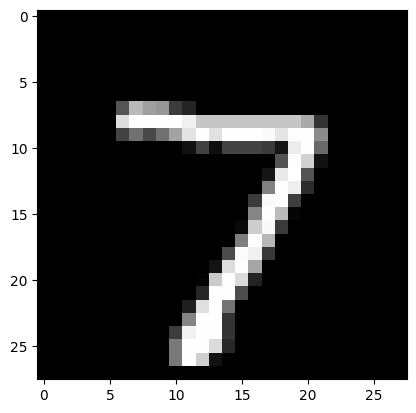

Model Prediction 7


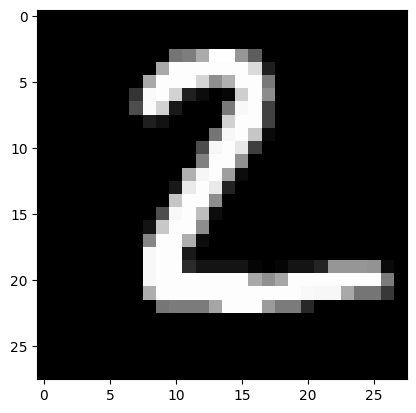

Model Prediction 2


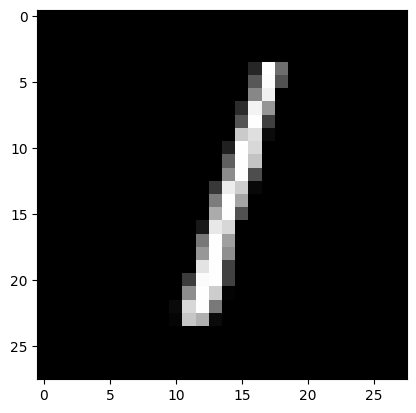

Model Prediction 1


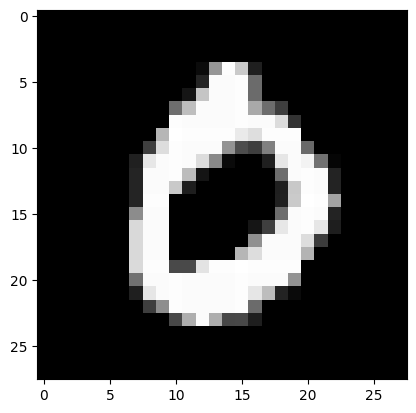

Model Prediction 0


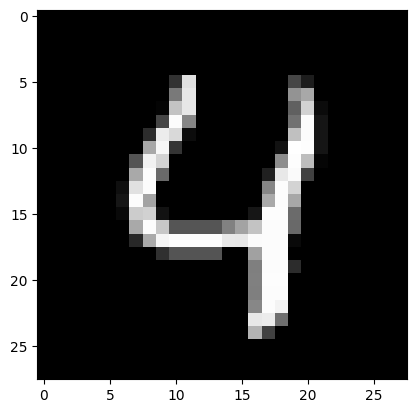

Model Prediction 4


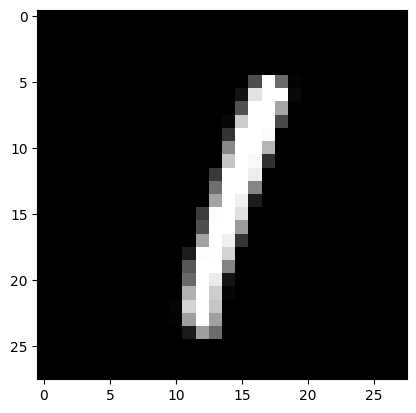

Model Prediction 1


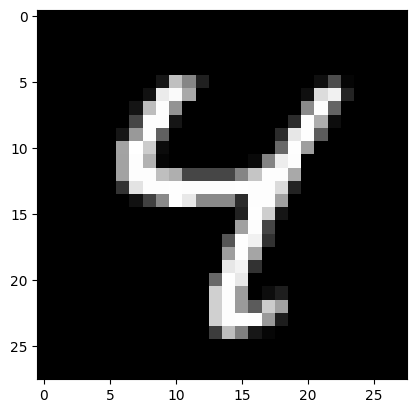

Model Prediction 4


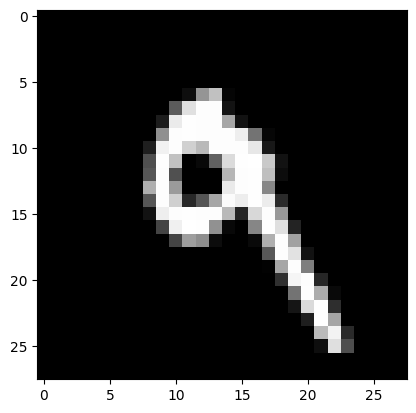

Model Prediction 9


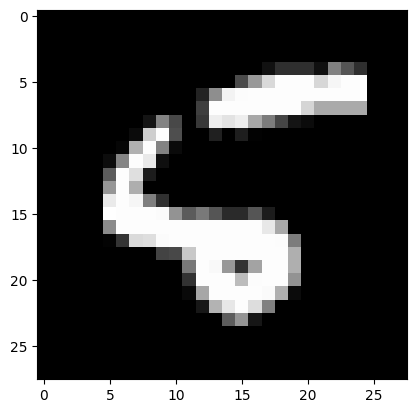

Model Prediction 6


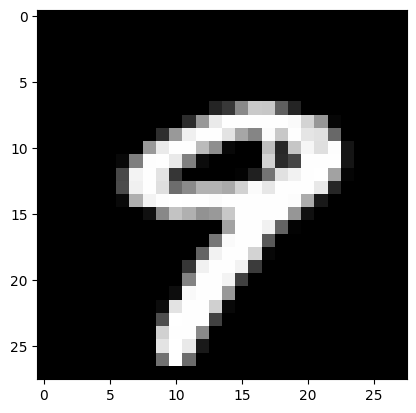

Model Prediction 9


In [12]:
import matplotlib.pyplot as plt

# Predict 10 images from the validation set
n_images = 10

test_images = x_test[:n_images]
#shape[10:784]

predictions = neural_net(test_images)

# Display image and model prediction
for i in range(n_images):
  plt.imshow(np.reshape(test_images[i],[28,28]),cmap='grey')
  plt.show()
  print(f"Model Prediction {np.argmax(predictions.numpy()[i])}")